In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = True
from scipy.integrate import quad
from scipy.optimize import minimize
import time
from numba import njit, prange
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from numba import njit

In [ ]:
# ── at the top of the notebook ──────────────────────────────────────────
from google.colab import drive
import os
import matplotlib # Import matplotlib here to modify its rcParams

drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/SVM_results"
os.makedirs(save_dir, exist_ok=True)

# Disable LaTeX rendering to avoid the 'latex not found' error
matplotlib.rcParams['text.usetex'] = False


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_and_convert_dataset(d=2000, p=1000, noise=1.0, seed=0):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((d, p))                  # random Gaussian entries
    x_star = rng.standard_normal(p)                  # ground-truth signal
    b = A @ x_star + noise * rng.standard_normal(d)  # noisy linear targets
    return A, b

In [ ]:
def step_sizes(a, block_vector, length_vector, cases, alpha1, acst, factor=1.9):
    beta2 = (1.0 + acst*acst) / (acst*acst)
    out = np.zeros(cases)
    for i in range(cases):
        block  = int(block_vector[i])
        length = int(length_vector[i])
        step = 0.0
        for l in range(block):
            start, end = l*length, (l+1)*length
            a_block = a[:, start:end]
            step = max(step, np.linalg.norm(a_block, ord=2)**2)
        out[i] = factor / (beta2 * (step + alpha1))
    return out

In [ ]:
A, B = load_and_convert_dataset()
a_train = A  # Alias for matrix A
a = a_train# Alias for matrix A
block_vector  = [1, 2, 100, 200, 1000]
length_vector = [1000, 500, 10, 5, 1]
cases = len(block_vector)
alpha1 = 1.0   # ridge weight in h(x)
acst   = 1.0   # constant a in f(x) = h(x) - 1/(h(x)+a)
learning_rate = step_sizes(a, block_vector, length_vector, cases, alpha1, acst, factor=1.9)
print(learning_rate)

[0.00016545 0.00021347 0.00039968 0.00040862 0.00043282]


In [ ]:
print(step_sizes(a, [1000], [1], 1, alpha1, acst, factor=1.9))

[0.00043282]


In [ ]:
@njit
def h_value(r, sq, alpha1, d):
    s = 0.0
    for i in range(d):
        s += r[i]*r[i]
    return 0.5*s + 0.5*alpha1*sq
@njit
def falpha(r, sq, alpha1, acst, d):
    hv = h_value(r, sq, alpha1, d)
    return hv - 1.0/(hv + acst)
@njit
def gprime_h(r, sq, alpha1, acst, d):
    """Scalar factor g'(h) = 1 + 1/(h+a)^2 in the stepsize."""
    hv = h_value(r, sq, alpha1, d)
    return 1.0 + 1.0/((hv + acst)*(hv + acst))
def f_star(A, b, alpha1, acst,p):
    xstar = np.linalg.solve(A.T @ A + alpha1 * np.eye(p), A.T @ b)
    r = A @ xstar - b
    hstar = 0.5 * (r @ r) + 0.5 * alpha1 * (xstar @ xstar)
    fstar = hstar - 1.0 / (hstar + acst)
    return fstar, xstar
def distance_history(X, xstar):
    """||x_k - x*||^2 per recorded iterate. X is (p, n_epochs+1). Cheap, post-hoc."""
    diff = X - xstar[:, None]
    return np.sum(diff*diff, axis=0)
def hitting_iter_time(F_gap, total_time, tol):
    below = np.where(F_gap <= tol)[0]
    if len(below) == 0:
        return None, None
    k = int(below[0]); n = len(F_gap) - 1
    return k, (total_time * k / n if n > 0 else 0.0)

NameError: name 'njit' is not defined

In [ ]:
@njit
def coordinate_descent(
    a, b,
    p, d,
    block, length,
    num_iterations,
    x0, random_blocks,
    learning_rate,
    alpha1, acst, r, sq, f0
):
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = r.copy()
    F_hist[0] = f0
    X[:, 0] = x
    total_iters = num_iterations * block

    for it in range(total_iters):
        blk = random_blocks[it]
        start = blk * length

        gprime = gprime_h(r, sq, alpha1, acst, d)

        for jj in range(length):
            col = start + jj
            gh = 0.0
            for i in range(d):
                gh += a[i, col] * r[i]
            gh += alpha1 * x[col]
            g = gprime * gh
            dx = -learning_rate * g
            sq += 2.0*x[col]*dx + dx*dx
            x[col] += dx
            for i in range(d):
                r[i] += a[i, col] * dx

        if it % block == 0:
            epoch = it // block
            F_hist[epoch+1] = falpha(r, sq, alpha1, acst, d)
            X[:, epoch+1] = x

    return x, F_hist, X

In [ ]:
def run_block_coordinate_descent_mc(p, d, cases, block_vector, length_vector,
                                    MC, num_iterations, Init, alpha1, acst,
                                    noise=1.0, factor=1.9, data_seed=0):
    """
    Block coordinate descent with a FRESH random (A,b) for every Monte-Carlo run.
    Stores the optimality gap  f - f*  (f* exact, per instance).

    Returns
    -------
    x_train : (p, cases, MC)
    F_CD    : (cases, num_iterations+1, MC)   -- holds  f - f*
    CD_time : (cases, MC)
    """
    x_train = np.zeros((p, cases, MC))
    F_CD    = np.zeros((cases, num_iterations+1, MC))
    E_CD    = np.zeros((cases, num_iterations+1, MC))
    CD_time = np.zeros((cases, MC))

    for mc in range(MC):
        # fresh data for this MC run
        A_mc, b_mc = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        # exact optimum for this instance
        fstar, xstar = f_star(A_mc, b_mc, alpha1, acst,p)
        # step sizes for THIS A
        lr_vec = step_sizes(A_mc, block_vector, length_vector, cases, alpha1, acst, factor=factor)
        x0 = Init[:, mc]
        x3 = x0.copy()
        for k in range(cases):
            block  = block_vector[k]
            length = length_vector[k]
            lr     = lr_vec[k]
            random_blocks = rng.randint(0, block, size=num_iterations*block)
            # residual r = A x - b
            r1 = np.zeros(d)
            for i in range(d):
                  s = 0.0
                  for j in range(p):
                      s += A_mc[i, j] * x3[j]
                  r1[i] = s - b_mc[i]
            # sq = ||x||^2
            sq1 = 0.0
            for j in range(p):
                  sq1 += x3[j]*x3[j]
            f0 = falpha(r1, sq1, alpha1, acst, d)
            t0 = time.time()
            x_final, F_hist, X = coordinate_descent(
                A_mc, b_mc, p, d, block, length,
                num_iterations, x0, random_blocks, lr, alpha1, acst,r1,sq1,f0)
            t1 = time.time()
            # distance ||x_k - x*||^2.
            for kk in range(num_iterations+1):
                E_CD[k, kk, mc] = np.linalg.norm(X[:, kk]-xstar)* np.linalg.norm(X[:, kk]-xstar)
            x_train[:, k, mc] = x_final
            F_CD[k, :, mc]    = F_hist - fstar      # store optimality gap
            CD_time[k, mc]    = t1 - t0
        print(f"MC {mc}: f* = {fstar:.4f}")

    return x_train, F_CD, CD_time, E_CD

In [ ]:
@njit
def gradient_descent(a, b, p, d, num_iterations, x0, learning_rate, alpha1, acst):
    """Full gradient descent on f = h - 1/(h+acst). The baseline to beat."""
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = np.empty(d)
    for i in range(d):
        s = 0.0
        for j in range(p):
            s += a[i, j]*x[j]
        r[i] = s - b[i]
    sq = 0.0
    for j in range(p):
        sq += x[j]*x[j]
    F_hist[0] = falpha(r, sq, alpha1, acst, d); X[:, 0] = x
    for it in range(num_iterations):
        gh = np.zeros(p)
        for i in range(d):
            ri = r[i]
            for j in range(p):
                gh[j] += a[i, j]*ri
        for j in range(p):
            dx = -learning_rate*(gh[j] + alpha1*x[j])
            sq += 2.0*x[j]*dx + dx*dx
            x[j] += dx
            for i in range(d):
                r[i] += a[i, j]*dx
        F_hist[it+1] = falpha(r, sq, alpha1, acst, d); X[:, it+1] = x
    return x, F_hist, X

In [ ]:
def plot_loss_functions(start, end, F_CD, block_vector, tol=1e-3,save_path="Coordinate_Descent.jpeg"):
    """
    Plot averaged loss with standard deviation bands.

    Parameters
    ----------
    start : int
        Initial iteration index.
    end : int
        Final iteration index (exclusive).
    F_CD : np.ndarray
        Array of shape (len(block_vector), n_iter, n_runs).
    block_vector : iterable
        Block sizes (or labels) to plot.
    save_path : str, optional
        Path to save the figure.
    """

    iterations = np.arange(start + 1, end)
    colors = ['aqua', 'maroon', 'fuchsia', 'orange', 'green',
              'yellow', 'pink', 'black']

    plt.figure(figsize=(10, 6))

    for count, t in enumerate(block_vector):
        if count >= len(colors):
            break  # avoid color overflow

        # Extract data
        loss_f = F_CD[count, start:end, :]

        # Mean and standard deviation over runs
        mean_value = np.mean(loss_f, axis=1)
        std_value = np.std(loss_f, axis=1)

        # Plot mean
        plt.plot(
            iterations,
            mean_value,
            label=f"Blocks {t}",
            color=colors[count],
            lw=2
        )

        # Shaded std region
        plt.fill_between(
            iterations,
            mean_value - std_value,
            mean_value + std_value,
            color=colors[count],
            alpha=0.2
        )

    # Axes and formatting
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Loss over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Averaged loss')
    #plt.grid(True, which="both", alpha=0.5)
    plt.axhline(tol, ls='--', c='gray', lw=1);
    plt.legend(fontsize='small')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

In [ ]:
def plot_error_iterations(start, end, E_CD, block_vector, tol=1e-3,save_path="Coordinate_Descent.jpeg"):
    """
    Plot averaged loss with standard deviation bands.

    Parameters
    ----------
    start : int
        Initial iteration index.
    end : int
        Final iteration index (exclusive).
    E_CD : np.ndarray
        Array of shape (len(block_vector), n_iter, n_runs).
    block_vector : iterable
        Block sizes (or labels) to plot.
    save_path : str, optional
        Path to save the figure.
    """

    iterations = np.arange(start + 1, end)
    colors = ['aqua', 'maroon', 'fuchsia', 'orange', 'green',
              'yellow', 'pink', 'black']

    plt.figure(figsize=(10, 6))

    for count, t in enumerate(block_vector):
        if count >= len(colors):
            break  # avoid color overflow

        # Extract data
        error_f = E_CD[count, start:end, :]

        # Mean and standard deviation over runs
        mean_value = np.mean(error_f, axis=1)
        std_value = np.std(error_f, axis=1)

        # Plot mean
        plt.plot(
            iterations,
            mean_value,
            label=f"Blocks {t}",
            color=colors[count],
            lw=2
        )

        # Shaded std region
        plt.fill_between(
            iterations,
            mean_value - std_value,
            mean_value + std_value,
            color=colors[count],
            alpha=0.2
        )

    # Axes and formatting
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Error over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    #plt.grid(True, which="both", alpha=0.5)
    plt.axhline(tol, ls='--', c='gray', lw=1);
    plt.legend(fontsize='small')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

In [ ]:
# Algorithm parameters
d = 2000          # samples (rows)
p = 1000          # features (columns) -- block*length must equal p
alpha1 = 1.0      # ridge weight in h(x)
acst   = 1.0      # constant a in f(x) = h(x) - 1/(h(x)+a)
noise  = 1.0      # noise level (sets the floor f* > 0)
MC_all = 10
iter_all = 200
tol=1e-3
block_vector  = [1, 2, 100, 200, 1000]
length_vector = [1000, 500, 10, 5, 1]
MC = MC_all
num_iterations = iter_all
cases = len(block_vector)
seed = 1
rng = np.random.RandomState(seed)
Init = rng.normal(0, 1, (p, MC))   # one shared init per MC (same x0 across cases)
data_seed = 1                    # base seed for per-MC data; instance mc uses data_seed+mc

In [ ]:
x_train, F_CD, CD_time, E_CD = run_block_coordinate_descent_mc(
    p, d, cases, block_vector, length_vector,
    MC, num_iterations, Init, alpha1, acst,
    noise=noise, factor=1.9, data_seed=data_seed)

MC 0: f* = 1005.4259
MC 1: f* = 1038.9364
MC 2: f* = 1038.6587
MC 3: f* = 1012.4856
MC 4: f* = 987.5750
MC 5: f* = 1028.4075
MC 6: f* = 1030.4819
MC 7: f* = 999.5503
MC 8: f* = 1027.5523
MC 9: f* = 1070.0433


In [ ]:
print(np.mean(CD_time, axis=1))

[1.80284677 1.63130548 1.80008867 2.01497672 3.62100751]


In [ ]:
cases = len(block_vector)
print("train f:", F_CD[:, num_iterations, MC-1])
print("train f:", E_CD[:, num_iterations, MC-1])

train f: [9.13969896e-04 4.29665995e-05 6.55290933e-10 2.59205990e-10
 1.25737643e-10]
train f: [9.63036381e-06 4.48854691e-07 7.07987780e-12 2.58538781e-12
 1.21652670e-12]


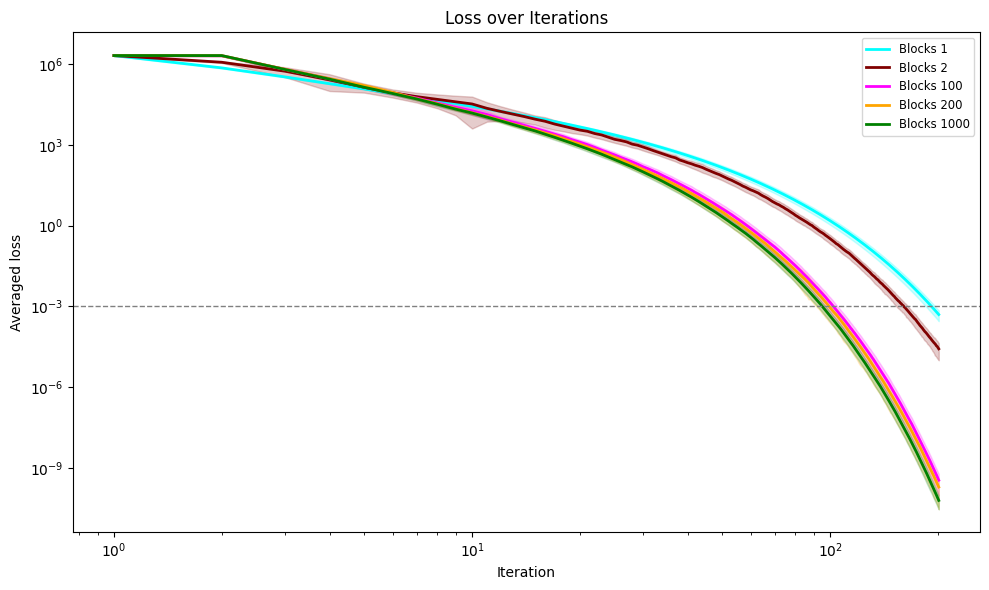

In [ ]:
import matplotlib
matplotlib.rcParams['text.usetex'] = False
start = 0
end = num_iterations+2
plot_loss_functions(start, end, F_CD, block_vector, tol, save_path="Coordinate_Descent0.1_20.jpeg")

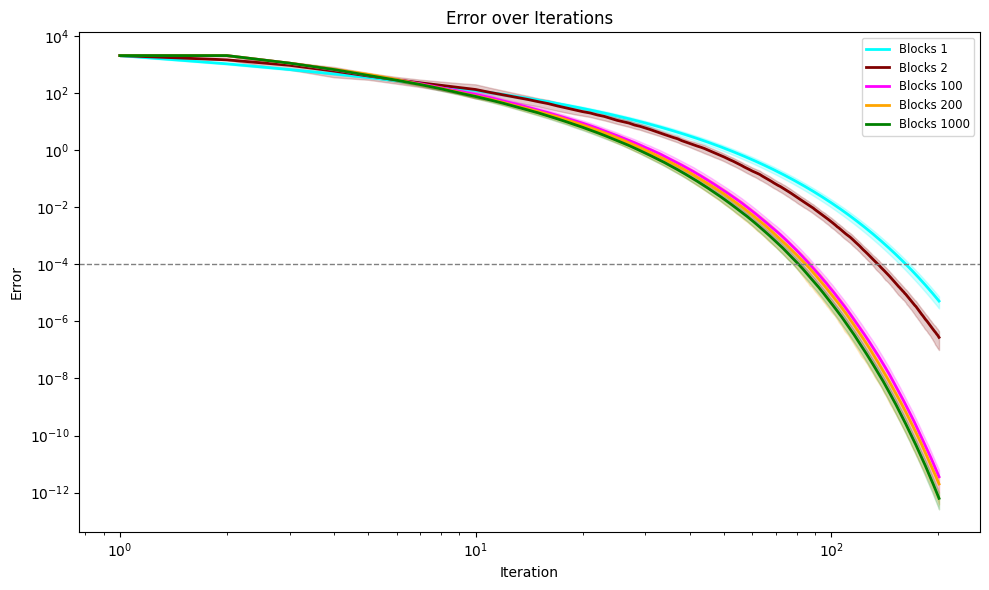

In [ ]:
matplotlib.rcParams['text.usetex'] = False
start = 0
tol=1e-4
end = num_iterations+2
plot_error_iterations(start, end, E_CD, block_vector, tol, save_path="Coordinate_Descent0.1_20.jpeg")

In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(F_CD[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-3)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    4.924e-04     1.803       191      1.722
       2    2.617e-05     1.631       160      1.305
     100    3.462e-10     1.800       101      0.909
     200    1.920e-10     2.015        99      0.997
    1000    6.122e-11     3.621        95      1.720


In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(E_CD[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-4)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    5.129e-06     1.803       162      1.460
       2    2.744e-07     1.631       135      1.101
     100    3.616e-12     1.800        86      0.774
     200    2.021e-12     2.015        84      0.846
    1000    6.347e-13     3.621        80      1.448


In [ ]:
def run_block_coordinate_descent_rand(
    p, d, cases, block_vector, length_vector,
    MC, num_iterations, Init, alpha1, acst,
    noise=1.0, factor=1.9, data_seed=0
):
    """Random-subset block CD, fresh (A,b) per MC. Stores gap f-f* (F) and distance ||x-x*||^2 (E)."""
    x_train_rand = np.zeros((p, cases, MC))
    F_CD_rand    = np.zeros((cases, num_iterations+1, MC))
    E_CD_rand    = np.zeros((cases, num_iterations+1, MC))
    CD_time_rand = np.zeros((cases, MC))


    for mc in range(MC):
        A_mc, b_mc = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        fstar, xstar = f_star(A_mc, b_mc, alpha1, acst, p)
        lr_vec = step_sizes(A_mc, block_vector, length_vector, cases, alpha1, acst, factor=factor)
        x0 = Init[:, mc].copy()
        x3 = x0.copy()
        for k in range(cases):
            block, length, lr = block_vector[k], length_vector[k], lr_vec[k]
            random_blocks = np.argsort(
                np.random.random((num_iterations * block, p)), axis=1
            )[:, :length].astype(np.int64)
            # residual r = A x - b
            r1 = np.zeros(d)
            for i in range(d):
                  s = 0.0
                  for j in range(p):
                      s += A_mc[i, j] * x3[j]
                  r1[i] = s - b_mc[i]
            # sq = ||x||^2
            sq1 = 0.0
            for j in range(p):
                  sq1 += x3[j]*x3[j]
            f0 = falpha(r1, sq1, alpha1, acst, d)
            t0 = time.time()
            x_f, F_hist, X = coordinate_descent_rand(
                A_mc, b_mc, p, d, block, length, num_iterations,
                x0, random_blocks, lr, alpha1, acst,r1,sq1,f0)
            t1 = time.time()
            diff = X - xstar[:, None]
            E_CD_rand[k, :, mc] = np.sum(diff*diff, axis=0)   # distance, post-hoc
            x_train_rand[:, k, mc] = x_f
            F_CD_rand[k, :, mc]    = F_hist - fstar
            CD_time_rand[k, mc]    = t1 - t0
        print(f"MC {mc}: f* = {fstar:.4f}")
    return x_train_rand, F_CD_rand, CD_time_rand, E_CD_rand

In [ ]:
@njit
def coordinate_descent_rand(
    a, b, p, d, block, length, num_iterations,
    x0, random_blocks, lr, alpha1, acst,r1,sq1,f0):
    """Random-subset block CD for f = h - 1/(h+acst). Returns x, F_hist, X (iterate history)."""
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = r1.copy()
    F_hist[0] = f0
    X[:, 0] = x
    sq = sq1
    F_hist[0] = falpha(r, sq, alpha1, acst, d)
    total_iters = num_iterations * block
    for it in range(total_iters):
        blk = random_blocks[it, :]
        gprime = gprime_h(r, sq, alpha1, acst, d)
        for jj in range(length):
            col = blk[jj]
            gh = 0.0
            for i in range(d):
                gh += a[i, col] * r[i]
            gh += alpha1 * x[col]
            dx = -lr * (gprime * gh)
            sq += 2.0*x[col]*dx + dx*dx
            x[col] += dx
            for i in range(d):
                r[i] += a[i, col] * dx
        if it % block == 0:
            epoch = it // block
            F_hist[epoch+1] = falpha(r, sq, alpha1, acst, d)
            X[:, epoch+1] = x
    return x, F_hist, X

In [ ]:
x_train_rand, F_CD_rand, CD_time_rand, E_CD_rand = run_block_coordinate_descent_rand(
    p, d, cases, block_vector, length_vector,
    MC, num_iterations, Init, alpha1, acst,
    noise=noise, factor=1.9, data_seed=data_seed)

MC 0: f* = 1005.4259
MC 1: f* = 1038.9364
MC 2: f* = 1038.6587
MC 3: f* = 1012.4856
MC 4: f* = 987.5750
MC 5: f* = 1028.4075
MC 6: f* = 1030.4819
MC 7: f* = 999.5503
MC 8: f* = 1027.5523
MC 9: f* = 1070.0433


In [ ]:
print(np.mean(CD_time_rand, axis=1))

[3.22935193 2.80734684 2.76900783 2.81104426 3.66467748]


In [ ]:
cases = len(block_vector)
print("train f:", F_CD_rand[:, num_iterations, MC-1])
print("train f:", E_CD_rand[:, num_iterations, MC-1])


train f: [1.02317829e-03 5.40572801e-05 1.80534698e-10 3.47881723e-11
 2.45563569e-11]
train f: [1.07693169e-05 5.65640155e-07 1.53849390e-12 2.79452188e-13
 4.35284011e-13]


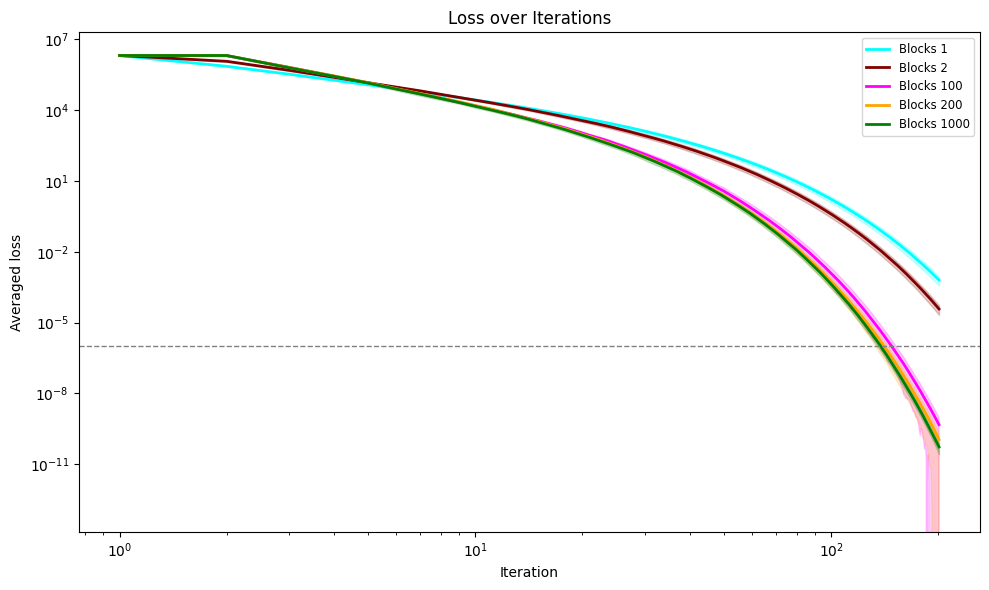

In [ ]:
matplotlib.rcParams['text.usetex'] = False
start = 0
end = num_iterations+2
plot_loss_functions(start, end, F_CD_rand, block_vector, 1e-6, save_path="Coordinate_Descent0.1_20.jpeg")

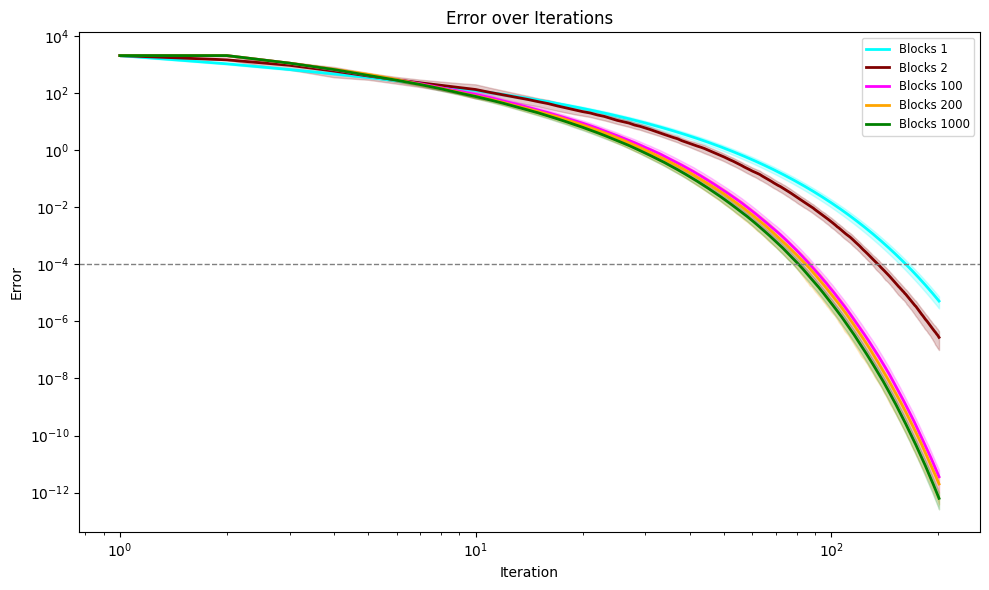

In [ ]:
matplotlib.rcParams['text.usetex'] = False
start = 0
tol=1e-4
end = num_iterations+2
plot_error_iterations(start, end, E_CD, block_vector, tol, save_path="Coordinate_Descent0.1_20.jpeg")

In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(F_CD_rand[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time_rand[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-3)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    6.337e-04     3.229       194      3.132
       2    3.765e-05     2.807       164      2.302
     100    4.701e-10     2.769       101      1.398
     200    1.102e-10     2.811        96      1.349
    1000    5.365e-11     3.665        94      1.722


In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(E_CD_rand[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time_rand[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-4)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    6.611e-06     3.229       164      2.648
       2    3.958e-07     2.807       139      1.951
     100    4.948e-12     2.769        86      1.191
     200    1.237e-12     2.811        81      1.138
    1000    5.551e-13     3.665        80      1.466


In [ ]:
def plot_loss_functions1(start, end, F_CD,tol):

    iterations =  range(start,end)
    print(len(iterations))
    colors=['aqua','orange','green','yellow','pink','black', 'maroon','fuchsia']
    Methods=['GD', 'NOUS_2 (our)','DOS_2 (our)','NOUS_100 (our)','DOS_100 (our)','Serial (our)', "SGD", "ZO"]
    count=0
    dim =F_CD.shape[0]
    for t in range(dim):
        # Compute mean and standard deviation for plotting shaded regions
        loss_f = F_CD[count, :, ]
        mean_value = np.mean(loss_f, axis = 1)
        print(mean_value.shape)
        print(mean_value[0])
        std_value = np.std(loss_f, axis = 1)
        # Plot of regret values over iterations
        # plt.figure(figsize=(10, 6))

        # Plot the mean regret line
        plt.plot(iterations, mean_value, label=Methods[count], color=colors[count], lw=2)
        plt.legend(loc='best',fontsize='small')
        # Plot shaded area (mean ± std_dev)
        # plt.fill_between(iterations, mean_regret - std_regret, mean_regret + std_regret,
        #              color=colors[count], alpha=0.2, label=f"Regret ± Std Dev with maximun delay {t}")
        plt.fill_between(iterations, mean_value - std_value, mean_value + std_value,
                     color=colors[count], alpha=0.2)
        count=count+1
    # Add labels and grid
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Averaged loss')
    plt.axhline(tol, ls='--', c='gray', lw=1)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig('Coordinate_Descent0.1_20.jpeg')
    plt.show()

In [ ]:
F_CD_all = np.zeros((6, num_iterations+1,MC))
F_CD_all[0,:,:] = F_CD[0,:,:]
F_CD_all[1,:,:] = F_CD[1,:,:]
F_CD_all[3,:,:] = F_CD[2,:,:]
F_CD_all[5,:,:] = F_CD[4,:,:]
F_CD_all[2,:,:] = F_CD_rand[1,:,:]
F_CD_all[4,:,:] = F_CD_rand[2,:,:]
start = 1
end = num_iterations+2

201
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635


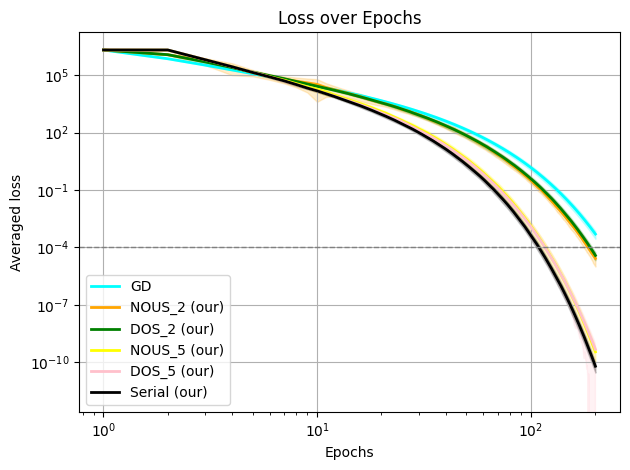

In [ ]:
plot_loss_functions1(start, end, F_CD_all,tol)

In [ ]:
@njit
def sgd_optimize(a, b, p, d, num_iterations, x0, learning_rate, batch_size, block_sgd,
                 alpha1, acst, all_batches):
    """SGD for f = h - 1/(h+acst). Stochastic grad h (row batch, d/B rescale), exact g'(h).
       Returns x, F_hist, X (iterate history)."""
    F_hist = np.zeros(num_iterations+1); X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = np.empty(d)
    for i in range(d):
        s = 0.0
        for j in range(p):
            s += a[i, j]*x[j]
        r[i] = s - b[i]
    sq = 0.0
    for j in range(p):
        sq += x[j]*x[j]
    F_hist[0] = falpha(r, sq, alpha1, acst, d); X[:, 0] = x
    scale = d/batch_size; total = block_sgd*num_iterations
    for it in range(total):
        gp = gprime_h(r, sq, alpha1, acst, d); bi = all_batches[it]
        grad = np.zeros(p)
        for s_ in range(batch_size):
            i = bi[s_]; ri = r[i]
            for j in range(p):
                grad[j] += a[i, j]*ri
        for j in range(p):
            dx = -learning_rate*(gp*(scale*grad[j] + alpha1*x[j]))
            sq += 2.0*x[j]*dx + dx*dx
            x[j] += dx
            for i in range(d):
                r[i] += a[i, j]*dx
        if (it + 1) % block_sgd == 0:
            ep = it//block_sgd; F_hist[ep+1] = falpha(r, sq, alpha1, acst, d); X[:, ep+1] = x
    return x, F_hist, X


def run_sgd_mc(p, d, MC, num_iterations, Init, alpha1, acst,
               batch_size=10, block_sgd=20, sgd_factor=0.1, noise=1.0, data_seed=1):
    """Monte-Carlo SGD: fresh (A,b) per run; stores gap f-f* (F_sgd) and ||x-x*||^2 (E_sgd)."""
    x_sgd = np.zeros((p, MC)); F_sgd = np.zeros((num_iterations+1, MC))
    E_sgd = np.zeros((num_iterations+1, MC)); time_sgd = np.zeros(MC)
    for mc in range(MC):
        sgd_factor = 0.12
        A, b = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        fstar, xstar = f_star(A, b, alpha1, acst, p)
        Lf = ((1+acst*acst)/(acst*acst))*(np.linalg.norm(A, 2)**2 + alpha1)
        x0 = Init[:, mc].copy()
        rs = np.random.RandomState(1000 + mc)
        all_batches = np.empty((block_sgd*num_iterations, batch_size), dtype=np.int64)
        for it in range(block_sgd*num_iterations):
            all_batches[it] = rs.choice(d, size=batch_size, replace=False)
        t0 = time.time()
        x_f, F_hist, X = sgd_optimize(A, b, p, d, num_iterations, x0,
                                      sgd_factor/Lf, batch_size, block_sgd, alpha1, acst, all_batches)
        time_sgd[mc] = time.time() - t0
        x_sgd[:, mc] = x_f
        F_sgd[:, mc] = F_hist - fstar
        diff = X - xstar[:, None]; E_sgd[:, mc] = np.sum(diff*diff, axis=0)
        print(f"SGD MC {mc}: f* = {fstar:.4f}")
    return x_sgd, F_sgd, time_sgd, E_sgd

In [ ]:
@njit
def zo_optimize(a, b, p, d, num_iterations, x0, learning_rate, h_fd, u_dirsT, alpha1, acst, r, sq, f0):
    """Zero-order: p random-direction forward finite differences per epoch.
       u_dirsT is (num_iterations*p, p) row-contiguous unit directions. Returns x, F_hist, X."""
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = r.copy()
    F_hist[0] = f0
    X[:, 0] = x
    lentgh= 1000
    total_iters = num_iterations*lentgh
    au = np.empty(d)
    for it in range(total_iters):
        u = u_dirsT[it]
        f_x = falpha(r, sq, alpha1, acst, d)
        xu = 0.0; uu = 0.0
        for j in range(p):
            xu += x[j]*u[j]
            uu += u[j]*u[j]
        for i in range(d):
            s = 0.0
            for j in range(p):
                s += a[i, j]*u[j]
            au[i] = s
        hv = 0.0
        for i in range(d):
            rp = r[i] + h_fd*au[i]
            hv += rp*rp
        sq_p = sq + 2.0*h_fd*xu + h_fd*h_fd*uu
        hvf = 0.5*hv + 0.5*alpha1*sq_p
        f_p = hvf - 1.0/(hvf + acst)
        ge = (f_p - f_x)/h_fd
        c = -learning_rate*ge
        for j in range(p):
            dxj = c*u[j]
            sq += 2.0*x[j]*dxj + dxj*dxj
            x[j] += dxj
        for i in range(d):
            r[i] += c*au[i]
        if it % lentgh == 0:
            epoch = it // lentgh
            F_hist[epoch+1] = f_x
            X[:, epoch+1] = x
    return x, F_hist, X
def run_zo_mc(p, d, MC, num_iterations, Init, alpha1, acst,
              h_zo=0.001, zo_factor=3.0, noise=1.0, data_seed=1):
    """Monte-Carlo zero-order: fresh (A,b) per run; stores gap f-f* and ||x-x*||^2."""
    x_zo = np.zeros((p, MC)); F_zo = np.zeros((num_iterations+1, MC))
    E_zo = np.zeros((num_iterations+1, MC)); time_zo = np.zeros(MC)
    for mc in range(MC):
        A, b = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        fstar, xstar = f_star(A, b, alpha1, acst, p)
        Lf = ((1+acst*acst)/(acst*acst))*(np.linalg.norm(A, 2)**2 + alpha1)
        lr = step_sizes(A, [1000], [1], 1, alpha1, acst, 1.9)
        lr = lr[0]
        x0 = Init[:, mc].copy()
        rs = np.random.RandomState(2000 + mc)
        # FIX 1: num_iterations*p directions to match total_iters = num_iterations*p
        U = rs.normal(0, 1, size=(p, num_iterations*p)); U /= np.sqrt((U**2).sum(0, keepdims=True))
        UT = np.ascontiguousarray(U.T)
        r1 = A @ x0 - b; sq1 = float(x0 @ x0); f0 = falpha(r1, sq1, alpha1, acst, d)
        t0 = time.time()
        x_f, F_hist, X = zo_optimize(A, b, p, d, num_iterations, x0,
                                     lr, h_zo, UT, alpha1, acst, r1, sq1, f0)
        time_zo[mc] = time.time() - t0
        x_zo[:, mc] = x_f
        F_zo[:, mc] = F_hist - fstar
        diff = X - xstar[:, None]; E_zo[:, mc] = np.sum(diff*diff, axis=0)
        print(f"ZO MC {mc}: f* = {fstar:.4f}")
    return x_zo, F_zo, time_zo, E_zo

In [ ]:
# SGD run
batch_size = 100
block_sgd  = 20
print("Running SGD...")
x_sgd, F_sgd, time_sgd, E_sgd = run_sgd_mc(
    p, d, MC, num_iterations, Init, alpha1, acst,
    batch_size=batch_size, block_sgd=block_sgd, sgd_factor=0.1,
    noise=noise, data_seed=data_seed)
print(f"SGD time (avg): {np.mean(time_sgd):.4f}s, final gap: {np.mean(F_sgd[-1]):.3e}")

Running SGD...
SGD MC 0: f* = 1005.4259
SGD MC 1: f* = 1038.9364
SGD MC 2: f* = 1038.6587
SGD MC 3: f* = 1012.4856
SGD MC 4: f* = 987.5750
SGD MC 5: f* = 1028.4075
SGD MC 6: f* = 1030.4819
SGD MC 7: f* = 999.5503
SGD MC 8: f* = 1027.5523
SGD MC 9: f* = 1070.0433
SGD time (avg): 22.8074s, final gap: 5.533e+01


In [ ]:
# Zero-order run
h_zo = 0.001
zo_factor = 3.0
print("Running Zero-Order...")
x_zo, F_zo, time_zo, E_zo = run_zo_mc(
    p, d, MC, num_iterations, Init, alpha1, acst,
    h_zo=h_zo, zo_factor=zo_factor, noise=noise, data_seed=data_seed)
print(f"ZO time (avg): {np.mean(time_zo):.4f}s, final gap: {np.mean(F_zo[-1]):.3e}")

Running Zero-Order...
ZO MC 0: f* = 1005.4259
ZO MC 1: f* = 1038.9364
ZO MC 2: f* = 1038.6587
ZO MC 3: f* = 1012.4856
ZO MC 4: f* = 987.5750
ZO MC 5: f* = 1028.4075
ZO MC 6: f* = 1030.4819
ZO MC 7: f* = 999.5503
ZO MC 8: f* = 1027.5523
ZO MC 9: f* = 1070.0433
ZO time (avg): 856.0362s, final gap: 1.866e-01


In [ ]:
# ===== Unified summary: CD, rand-CD, SGD, ZO with the SAME criteria =====
# final gap (mean over MC), runtime, and iter/time to reach tol (on the averaged gap curve).
tol =1e-3
def hit_inline(mean_gap, tt, tol):
    n = len(mean_gap) - 1
    below = np.where(mean_gap <= tol)[0]
    if len(below) == 0:
        return "never", "never"
    ki = int(below[0]); ti = tt*ki/n if n > 0 else 0.0
    return f"{ki:.0f}", f"{ti:.3f}"

print(f"{'method':>14s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
# block CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(F_CD[k, :, :], axis=1); tt = np.mean(CD_time[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'CD blocks '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# rand CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(F_CD_rand[k, :, :], axis=1); tt = np.mean(CD_time_rand[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'rand '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# SGD
mg = np.mean(F_sgd, axis=1); tt = np.mean(time_sgd); hi, ht = hit_inline(mg, tt, tol)
print(f"{'SGD':>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# ZO
mg = np.mean(F_zo, axis=1); tt = np.mean(time_zo); hi, ht = hit_inline(mg, tt, tol)
print(f"{'ZO':>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")

        method    final gap   time(s)  iter@tol   time@tol
   CD blocks 1    4.924e-04     1.803       191      1.722
   CD blocks 2    2.617e-05     1.631       160      1.305
 CD blocks 100    3.462e-10     1.800       101      0.909
 CD blocks 200    1.920e-10     2.015        99      0.997
CD blocks 1000    6.122e-11     3.621        95      1.720
        rand 1    6.337e-04     3.229       194      3.132
        rand 2    3.765e-05     2.807       164      2.302
      rand 100    4.701e-10     2.769       101      1.398
      rand 200    1.102e-10     2.811        96      1.349
     rand 1000    5.365e-11     3.665        94      1.722
           SGD    5.533e+01    22.807     never      never
            ZO    1.866e-01   856.036     never      never


In [ ]:
F_CD_all = np.zeros((8, num_iterations+1,MC))
F_CD_all[0,:] = F_CD[0,:,:]
F_CD_all[1,:] = F_CD[1,:,:]
F_CD_all[3,:] = F_CD[2,:,:]
F_CD_all[5,:] = F_CD[4,:,:]
F_CD_all[2,:] = F_CD_rand[1,:,:]
F_CD_all[4,:] = F_CD_rand[2,:,:]
F_CD_all[6,:] = F_sgd[:,:]
F_CD_all[7,:] = F_zo[:,:]

201
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635
(201,)
2059235.2460730635


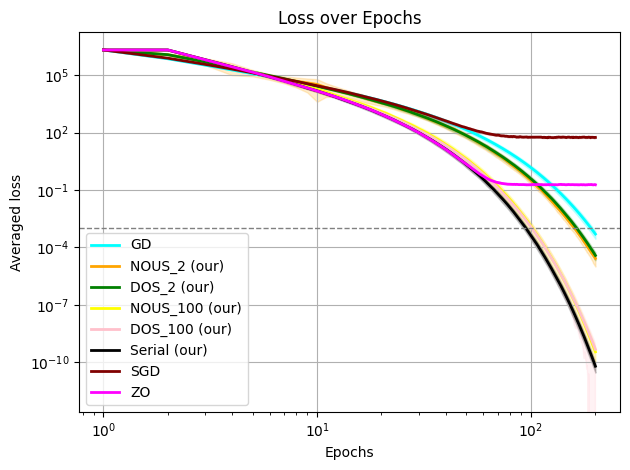

In [ ]:
tol =1e-3
plot_loss_functions1(start, end, F_CD_all,tol)

In [ ]:
def plot_loss_functions2(start, end, F_CD,tol):

    iterations =  range(start,end)
    print(len(iterations))
    colors=['aqua','orange','green','yellow','pink','black', 'maroon','fuchsia']
    Methods=['GD', 'NOUS_2 (our)','DOS_2 (our)','NOUS_100 (our)','DOS_100 (our)','Serial (our)', "SGD", "ZO"]
    count=0
    dim =F_CD.shape[0]
    for t in range(dim):
        # Compute mean and standard deviation for plotting shaded regions
        loss_f = F_CD[count, :, ]
        mean_value = np.mean(loss_f, axis = 1)
        print(mean_value.shape)
        print(mean_value[0])
        std_value = np.std(loss_f, axis = 1)
        # Plot of regret values over iterations
        # plt.figure(figsize=(10, 6))

        # Plot the mean regret line
        plt.plot(iterations, mean_value, label=Methods[count], color=colors[count], lw=2)
        plt.legend(loc='best',fontsize='small')
        # Plot shaded area (mean ± std_dev)
        # plt.fill_between(iterations, mean_regret - std_regret, mean_regret + std_regret,
        #              color=colors[count], alpha=0.2, label=f"Regret ± Std Dev with maximun delay {t}")
        plt.fill_between(iterations, mean_value - std_value, mean_value + std_value,
                     color=colors[count], alpha=0.2)
        count=count+1
    # Add labels and grid
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Iteration error over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Averaged iteration error')
    plt.axhline(tol, ls='--', c='gray', lw=1)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig('Coordinate_Descent0.1_20.jpeg')
    plt.show()

In [ ]:
E_CD_all = np.zeros((8, num_iterations+1,MC))
E_CD_all[0,:] = E_CD[0,:,:]
E_CD_all[1,:] = E_CD[1,:,:]
E_CD_all[3,:] = E_CD[2,:,:]
E_CD_all[5,:] = E_CD[4,:,:]
E_CD_all[2,:] = E_CD_rand[1,:,:]
E_CD_all[4,:] = E_CD_rand[2,:,:]
E_CD_all[6,:] = E_sgd[:,:]
E_CD_all[7,:] = E_zo[:,:]
tol =1e-3

In [ ]:
# ===== Unified summary: CD, rand-CD, SGD, ZO with the SAME criteria =====
# final gap (mean over MC), runtime, and iter/time to reach tol (on the averaged gap curve).
def hit_inline(mean_gap, tt, tol):
    n = len(mean_gap) - 1
    below = np.where(mean_gap <= tol)[0]
    if len(below) == 0:
        return "never", "never"
    ki = int(below[0]); ti = tt*ki/n if n > 0 else 0.0
    return f"{ki:.0f}", f"{ti:.3f}"

print(f"{'method':>14s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
# block CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(E_CD[k, :, :], axis=1); tt = np.mean(CD_time[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'CD blocks '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# rand CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(E_CD_rand[k, :, :], axis=1); tt = np.mean(CD_time_rand[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'rand '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# SGD
mg = np.mean(E_sgd, axis=1); tt = np.mean(time_sgd); hi, ht = hit_inline(mg, tt, tol)
print(f"{'SGD':>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# ZO
mg = np.mean(E_zo, axis=1); tt = np.mean(time_zo); hi, ht = hit_inline(mg, tt, tol)
print(f"{'ZO':>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")

        method    final gap   time(s)  iter@tol   time@tol
   CD blocks 1    5.129e-06     1.803       132      1.190
   CD blocks 2    2.744e-07     1.631       111      0.905
 CD blocks 100    3.616e-12     1.800        72      0.648
 CD blocks 200    2.021e-12     2.015        70      0.705
CD blocks 1000    6.347e-13     3.621        67      1.213
        rand 1    6.611e-06     3.229       134      2.164
        rand 2    3.958e-07     2.807       114      1.600
      rand 100    4.948e-12     2.769        71      0.983
      rand 200    1.237e-12     2.811        67      0.942
     rand 1000    5.551e-13     3.665        66      1.209
           SGD    5.566e-02    22.807     never      never
            ZO    3.718e-04   856.036        69    295.333


201
(201,)
2020.512775800157
(201,)
2020.512775800157
(201,)
2020.512775800157
(201,)
2020.512775800157
(201,)
2020.512775800157
(201,)
2020.512775800157
(201,)
2020.512775800157
(201,)
2020.512775800157


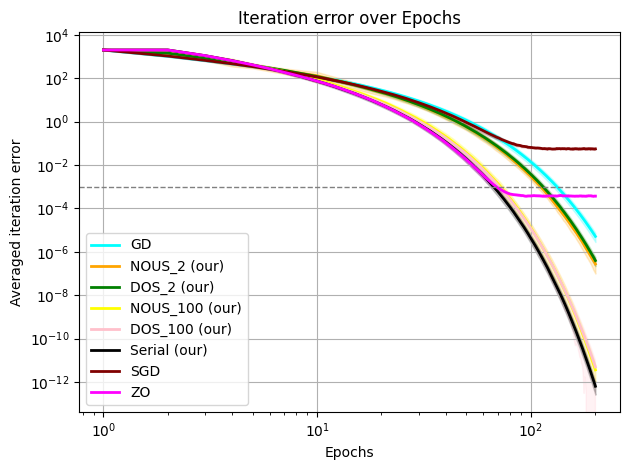

In [ ]:
tol =1e-3
plot_loss_functions2(start, end, E_CD_all,tol)